**Ноутбук 26 команды**

Дмитрий Белов

Сергей Поджарых

Диас Досанбеков

# 1. Подготовка к обучению

### 1.1 Выбираем прессет 

In [1]:
# Сохранение весов (True = сохранять и загружать)
SAVE_WEIGHTS = True
WEIGHTS_PATH = "best_model.pth"

# ============================================
# НАСТРОЙКА ОКРУЖЕНИЯ (ручное переключение)
# ============================================
# Раскомментируй нужную строку:

ENV = "windows"
#ENV = "kaggle"
# ENV = "colab"

# ============================================
# Параметры под выбранное окружение
# ============================================

if ENV == "windows":
    print("Режим: Linux (локальный ПК)")
    NUM_WORKERS = 4
    PIN_MEMORY = True
    BATCH_SIZE = 96
    IMG_SIZE = 256
    USE_ROTATION = True
    USE_COLOR_JITTER = True
    BASE_PATH = '/home/wamolve/Документы/PythonFiles/Project Kaggle 1/dataset'
    FILTER = True

elif ENV == "kaggle":
    print("Режим: Kaggle")
    NUM_WORKERS = 4
    PIN_MEMORY = True
    BATCH_SIZE = 96
    IMG_SIZE = 256
    USE_ROTATION = True
    USE_COLOR_JITTER = True
    USE_GAUSSIAN_BLUR = True # DOBAVIL
    BASE_PATH = '/kaggle/input/competitions/ml-intensive-yandex-academy-spring-2026/dataset'
    FILTER = True

elif ENV == "colab":
    print("Режим: Google Colab")
    NUM_WORKERS = 8
    PIN_MEMORY = True
    BATCH_SIZE = 64
    IMG_SIZE = 256
    USE_ROTATION = True
    USE_COLOR_JITTER = True
    BASE_PATH = "/content/drive/MyDrive/dataset/"
    FILTER = True
    WEIGHTS_PATH = '/content/drive/MyDrive/best_model.pth'

else:
    raise ValueError("ENV должен быть 'windows', 'kaggle' или 'colab'")

print(f"   Workers: {NUM_WORKERS}, Batch size: {BATCH_SIZE}, Image size: {IMG_SIZE}")

Режим: Linux (локальный ПК)
   Workers: 4, Batch size: 96, Image size: 256


у сокомандника был линукс, да

### 1.2 Импорт библиотек

In [ ]:
# # Улучшенная модель для задачи классификации (Kaggle)
#
# - Ручная CNN с residual‑блоками и GlobalAvgPooling
# - Аугментации (повороты, отражения, изменение цвета)
# - Стратифицированное разбиение + веса классов
# - ReduceLROnPlateau + Early stopping
# - Оценка F1 на валидации
# дата добавления 10.04.25

import warnings
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import transforms
from torchvision.transforms import v2 as T
from torch.cuda.amp import autocast, GradScaler
from PIL import Image
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
import cv2

warnings.filterwarnings('ignore')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

/home/wamolve/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Using device: cuda


### 1.3 Создаем кастомный класс для датасетов

Т.к. у нас есть ответы только для train_images

In [3]:
class ImageDatasetFromCSV(Dataset):
    def __init__(self, img_dir, csv_file=None, transform=None, img_ext='.jpg', has_labels=True):
        self.img_dir = img_dir
        self.transform = transform
        self.img_ext = img_ext
        self.has_labels = has_labels

        if self.has_labels:
            self.df = pd.read_csv(csv_file, header=None, names=['id', 'label'])
            self.ids = self.df['id'].values
            self.labels = self.df['label'].values
        else:
            self.images = sorted([f for f in os.listdir(img_dir) if f.endswith(img_ext)])
            self.ids = [int(os.path.splitext(f)[0]) for f in self.images]

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        img_id = int(self.ids[idx])
        img_path = os.path.join(self.img_dir, f"{img_id}{self.img_ext}")
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        if self.has_labels:
            label = int(self.labels[idx])
            return image, label
        else:
            return image, img_id

# 2. Подготовка данных к обучению

### 2.1 Вычисляем mean и std (потребуются для нормализации)

In [4]:
def compute_mean_std_full(img_dir, csv_file, batch_size=128):
    """Вычисляет mean и std по всем тренировочным изображениям."""
    dataset = ImageDatasetFromCSV(img_dir, csv_file, transform=transforms.ToTensor(), has_labels=True)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=2)
    mean = 0.0
    std = 0.0
    total_pixels = 0
    for images, _ in tqdm(loader, desc="Computing mean/std"):
        batch_samples = images.size(0)
        images = images.view(batch_samples, images.size(1), -1)
        mean += images.mean(2).sum(0)
        std += images.std(2).sum(0)
        total_pixels += batch_samples
    mean /= total_pixels
    std /= total_pixels
    return mean, std

TRAIN_IMG_DIR = f'{BASE_PATH}/train_images'
TRAIN_CSV = f'{BASE_PATH}/train_solution.csv'
TEST_IMG_DIR = f'{BASE_PATH}/test_images'

means = torch.tensor([0.5276, 0.4336, 0.3885])
stds = torch.tensor([0.2854, 0.2654, 0.2649])


### 2.2 Создаем класс фильтра для удаления шума

Удаляет шум с изображения, заменяя каждый пиксель на медиану значений пикселей в окружающей области (окне) размером kernel_size x kernel_size

In [5]:
class MedianFilter:
    def __init__(self, kernel_size=3):
        self.kernel_size = kernel_size
    def __call__(self, img):
        img_np = np.array(img)
        filtered = cv2.medianBlur(img_np, self.kernel_size)
        return Image.fromarray(filtered)

### 2.3 Аугментация данных

In [ ]:
train_transform = transforms.Compose([])

train_transform.transforms.extend([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5) # Отражения с вероятностью 0.5
])

if FILTER:
    train_transform.transforms.append(MedianFilter(kernel_size=3)) # Применяем фильтр 

if USE_ROTATION:
    train_transform.transforms.append(transforms.RandomRotation(10)) # Случайный поворот изображения в диапазоне от -10 до +10 градусов
# Cлучайное изменение яркости (±20%), контраста (±20%) и насыщенности (±10%)    
if USE_COLOR_JITTER:
    train_transform.transforms.append(transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1)) 
    
train_transform.transforms.extend([
    transforms.ToTensor(),
    transforms.Normalize(mean=means, std=stds) # Нормализация данных
])

# Для валидации:
val_transform = transforms.Compose([])

val_transform.transforms.extend([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
])

if FILTER:
    val_transform.transforms.append(MedianFilter(kernel_size=3))

val_transform.transforms.extend([
    transforms.ToTensor(),
    transforms.Normalize(mean=means, std=stds)
])

Загружаем данные

In [7]:
full_train_dataset = ImageDatasetFromCSV(
    img_dir=TRAIN_IMG_DIR,
    csv_file=TRAIN_CSV,
    transform=train_transform,
    has_labels=True
)


Т.к. ответы даны толко на train_images, то мы решили поделить его на мини-тестовый датасет(val_dataset) и собственно трейновый.

In [8]:
all_labels = full_train_dataset.labels

train_idx, val_idx = train_test_split(
    np.arange(len(full_train_dataset)),
    test_size=0.1,
    stratify=all_labels,
    random_state=42
)

train_dataset = Subset(full_train_dataset, train_idx)
val_dataset = Subset(full_train_dataset, val_idx)

print(f"Train size: {len(train_dataset)}, Val size: {len(val_dataset)}")

Train size: 45000, Val size: 5000


Очистка памяти GPU перед обучением

In [9]:
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()
import gc
gc.collect()

92

# 3. Создание и обучение модели

### 3.1 Конечная архитектура модели, к которой мы пришли

In [10]:
class DeeperCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()

        def conv_block(in_ch, out_ch, kernel=3, stride=1, padding=1):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel, stride, padding, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.LeakyReLU(0.2, inplace=True)
            )

        # Энкодер с бóльшим числом каналов
        self.encoder = nn.Sequential(
            conv_block(3, 64),      # 256
            nn.MaxPool2d(2),        # 128
            conv_block(64, 128),
            nn.MaxPool2d(2),        # 64
            conv_block(128, 256),
            nn.MaxPool2d(2),        # 32
            conv_block(256, 512),
            nn.MaxPool2d(2),        # 16
            conv_block(512, 512),
            nn.MaxPool2d(2),        # 8
            conv_block(512, 512),   # дополнительный блок без пулинга
        )

        self.res_blocks = nn.ModuleList([
            self._make_res(512, 512) for _ in range(4)
        ])

        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def _make_res(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch)
        )

    def forward(self, x):
        x = self.encoder(x)
        for block in self.res_blocks:
            identity = x
            x = block(x)
            x = x + identity
        x = self.global_pool(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

### 3.2 Функции для сохранения и загрузки весов модели

In [11]:
def save_model(model, optimizer, scheduler, epoch, best_val_loss, path=WEIGHTS_PATH):
    """Сохраняет модель и состояние обучения"""
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'best_val_loss': best_val_loss,
    }, path)
    print(f"Модель сохранена: {path}")

def load_model(model, optimizer, scheduler, path=WEIGHTS_PATH):
    """Загружает модель и состояние обучения"""
    if not os.path.exists(path):
        print(f"Файл {path} не найден. Начинаем обучение с нуля.")
        return 0, float('inf')

    checkpoint = torch.load(path)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    epoch = checkpoint['epoch']
    best_val_loss = checkpoint['best_val_loss']

    print(f"Загружена модель из {path} (эпоха {epoch}, best_val_loss={best_val_loss:.4f})")
    return epoch, best_val_loss

### 3.3 Функции для обучения

In [12]:
def train_epoch(model, loader, optimizer, loss_fn, device, scaler):
    model.train()
    total_loss = 0
    total_correct = 0
    for x, y in tqdm(loader, desc="Training"):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        
        with autocast():
            out = model(x)
            loss = loss_fn(out, y)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        total_loss += loss.item()
        total_correct += (out.argmax(dim=1) == y).sum().item()
    return total_loss / len(loader), total_correct / len(loader.dataset)

def train_epoch_accum(model, loader, optimizer, loss_fn, device, scaler, accum_steps=1):
    model.train()
    total_loss = 0
    total_correct = 0
    optimizer.zero_grad()
    for i, (x, y) in enumerate(tqdm(loader, desc="Training")):
        x, y = x.to(device), y.to(device)
        with autocast():
            out = model(x)
            loss = loss_fn(out, y) / accum_steps
        
        scaler.scale(loss).backward()
        
        if (i + 1) % accum_steps == 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
        
        total_loss += loss.item() * accum_steps
        total_correct += (out.argmax(dim=1) == y).sum().item()
    return total_loss / len(loader), total_correct / len(loader.dataset)

@torch.inference_mode()
def evaluate(model, loader, loss_fn, device):
    model.eval()
    total_loss = 0
    total_correct = 0
    all_preds = []
    all_labels = []
    for x, y in tqdm(loader, desc="Evaluating"):
        x, y = x.to(device), y.to(device)
        with autocast():
            out = model(x)
            loss = loss_fn(out, y)
        total_loss += loss.item()
        preds = out.argmax(dim=1)
        total_correct += (preds == y).sum().item()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())
    f1 = f1_score(all_labels, all_preds, average='binary')
    return total_loss / len(loader), total_correct / len(loader.dataset), f1

### 3.4 Настройка обучения: DataLoader'ы, модель, loss и оптимизатор

In [13]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

In [14]:
model = DeeperCNN(num_classes=2).to(device)
from torchsummary import summary
summary(model, input_size=(3, 256, 256))

# Вычисляем веса классов для борьбы с дисбалансом
class_counts = np.bincount(all_labels)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum()
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
loss_fn = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

Layer (type:depth-idx)                   Param #
├─Sequential: 1-1                        --
|    └─Sequential: 2-1                   --
|    |    └─Conv2d: 3-1                  1,728
|    |    └─BatchNorm2d: 3-2             128
|    |    └─LeakyReLU: 3-3               --
|    └─MaxPool2d: 2-2                    --
|    └─Sequential: 2-3                   --
|    |    └─Conv2d: 3-4                  73,728
|    |    └─BatchNorm2d: 3-5             256
|    |    └─LeakyReLU: 3-6               --
|    └─MaxPool2d: 2-4                    --
|    └─Sequential: 2-5                   --
|    |    └─Conv2d: 3-7                  294,912
|    |    └─BatchNorm2d: 3-8             512
|    |    └─LeakyReLU: 3-9               --
|    └─MaxPool2d: 2-6                    --
|    └─Sequential: 2-7                   --
|    |    └─Conv2d: 3-10                 1,179,648
|    |    └─BatchNorm2d: 3-11            1,024
|    |    └─LeakyReLU: 3-12              --
|    └─MaxPool2d: 2-8                    --
| 

### 3.5 Цикл обучения с ранней остановкой

Для воспроизвеения обучения модели выберите и отредкатиурйте под ваше железо один из прессетов в начале (BASE_PATH, PIN_MEMORY и NUM_WORKERS - 2 ячейка). Также отредактировать пути к месту сохранения/загрузки весов модели (WEIGHTS_PATH - 1 ячейка).

Т.к. Обучали на несколких платформах сразу + иногда из-за Early Stop приходилось снова запускать обучение с сохраненным результатом и дообучать, в данном ноутбуке обучение начиналось с 37 эпохи (Но дальше модель уже вышла на плато и результаты были хуже)

In [ ]:
num_epochs = 55
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)
early_stop_patience = 12
best_val_loss = float('inf')
epochs_no_improve = 0
best_model_state = None
ACCUMULATION_STEPS = 3   # физический batch=96, эффективный=288

train_losses, val_losses = [], []
train_accs, val_accs, val_f1s = [], [], []

# Очистка памяти
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()
scaler = GradScaler()

# Загрузка весов, если есть
start_epoch = 0
if SAVE_WEIGHTS and os.path.exists(WEIGHTS_PATH):
    checkpoint = torch.load(WEIGHTS_PATH)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    start_epoch = checkpoint['epoch']
    best_val_loss = checkpoint['best_val_loss']
    print(f"Загружена модель с эпохи {start_epoch}, лучшая ошибка = {best_val_loss:.4f}")

for epoch in range(start_epoch, num_epochs):
    # Используем функцию с аккумуляцией градиентов
    train_loss, train_acc = train_epoch_accum(model, train_loader, optimizer, loss_fn, device, scaler, accum_steps=ACCUMULATION_STEPS)
    val_loss, val_acc, val_f1 = evaluate(model, val_loader, loss_fn, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    val_f1s.append(val_f1)

    scheduler.step(val_loss)

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, Val F1: {val_f1:.4f}")
    print(f"Current LR: {optimizer.param_groups[0]['lr']:.2e}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        best_model_state = copy.deepcopy(model.state_dict())
        if SAVE_WEIGHTS:
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'best_val_loss': best_val_loss,
            }, WEIGHTS_PATH)
            print(f"  -> Новая лучшая модель сохранена в {WEIGHTS_PATH}")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= early_stop_patience:
            print(f"Ранняя остановка после {epoch+1} эпох")
            break

model.load_state_dict(best_model_state)
print("Лучшая модель за эту сессию восстановлена")

Загружена модель с эпохи 37, лучшая ошибка = 0.1050


Evaluating: 100%|██████████| 53/53 [00:05<00:00,  9.13it/s]


Epoch 38/55
Train Loss: 0.0056, Train Acc: 0.9983
Val Loss: 0.1236, Val Acc: 0.9812, Val F1: 0.9451
Current LR: 1.00e-03


Evaluating: 100%|██████████| 53/53 [00:05<00:00,  8.97it/s]


Epoch 39/55
Train Loss: 0.0299, Train Acc: 0.9893
Val Loss: 0.2034, Val Acc: 0.9754, Val F1: 0.9248
Current LR: 1.00e-03


...

Epoch 47/55
Train Loss: 0.0248, Train Acc: 0.9916
Val Loss: 0.2060, Val Acc: 0.9766, Val F1: 0.9296
Current LR: 1.00e-03


Evaluating: 100%|██████████| 53/53 [00:06<00:00,  7.95it/s]


Epoch 48/55
Train Loss: 0.0217, Train Acc: 0.9930
Val Loss: 0.1216, Val Acc: 0.9774, Val F1: 0.9346
Current LR: 1.00e-03


Evaluating: 100%|██████████| 53/53 [00:06<00:00,  7.93it/s]


Epoch 49/55
Train Loss: 0.0210, Train Acc: 0.9924
Val Loss: 0.1632, Val Acc: 0.9720, Val F1: 0.9194
Current LR: 1.00e-03
Ранняя остановка после 49 эпох


### 3.6 Вывод результатов

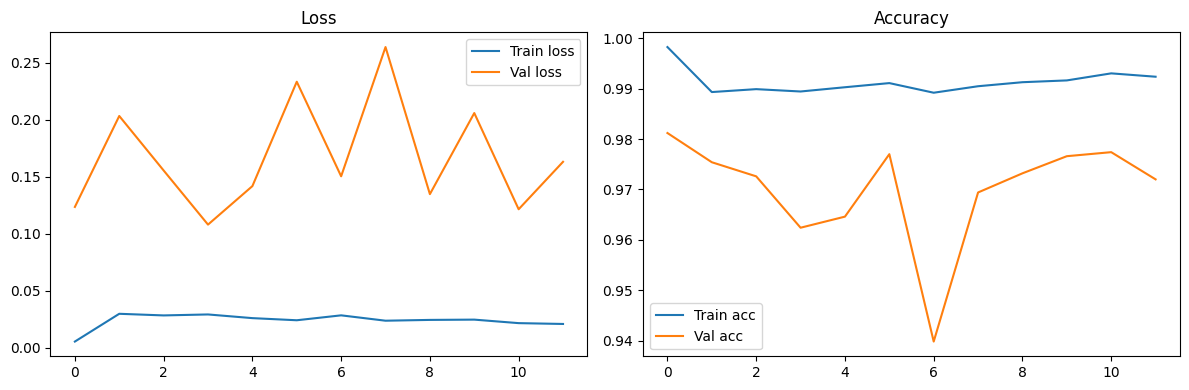

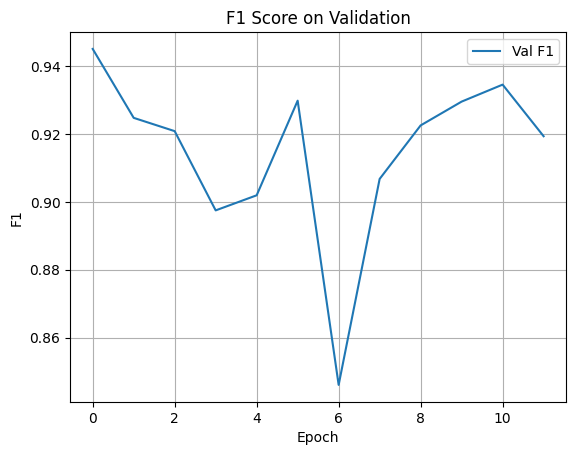

In [16]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(train_losses, label='Train loss')
plt.plot(val_losses, label='Val loss')
plt.legend()
plt.title('Loss')

plt.subplot(1,2,2)
plt.plot(train_accs, label='Train acc')
plt.plot(val_accs, label='Val acc')
plt.legend()
plt.title('Accuracy')

plt.tight_layout()
plt.savefig('training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

plt.figure()
plt.plot(val_f1s, label='Val F1')
plt.legend()
plt.title('F1 Score on Validation')
plt.xlabel('Epoch')
plt.ylabel('F1')
plt.grid(True)
plt.savefig('f1_score.png', dpi=300, bbox_inches='tight')
plt.show()

In [17]:
test_dataset = ImageDatasetFromCSV(
    img_dir=TEST_IMG_DIR,
    transform=val_transform,
    has_labels=False
)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

model.eval()
all_preds = []
all_ids = []
with torch.no_grad():
    for images, img_ids in tqdm(test_loader, desc="Testing"):
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_ids.extend(img_ids.numpy())

submission = pd.DataFrame({'id': all_ids, 'target_feature': all_preds})
submission.to_csv('submission_improved.csv', index=False)
print("submission_improved.csv created")
print(submission.head(10))

Testing: 100%|██████████| 105/105 [00:42<00:00,  2.48it/s]

submission_improved.csv created
     id  target_feature
0     0               1
1     1               1
2    10               0
3   100               0
4  1000               0
5  1001               0
6  1002               0
7  1003               1
8  1004               1
9  1005               1


## Итоги экспериментов и выводы

### Лучшая модель
Собственная архитектура: **DeeperCNN** - ручная сверточная сеть с 4 residual-блоками, GlobalAvgPooling и dropout (0.4/0.3).  
Размер входного изображения: **256×256**.  
Эффективный batch size: **288** (физический 96 × накопление 3 шагов, в осноновном использовали для оптимизации на железе **Nvidia 3060TI 8GB**).

### Обучение
- **Функция потерь**: CrossEntropyLoss с весами классов для борьбы с дисбалансом.
- **Оптимизатор**: AdamW (lr=1e-3, weight_decay=1e-4).
- **Планировщик**: CosineAnnealingLR (T_max=55, eta_min=1e-6) и ReduceLROnPlateau (Лучший).
- **Ранняя остановка**: 12 эпох без улучшения validation loss.
- **Аугментации**: RandomHorizontalFlip, RandomRotation(10°), ColorJitter (яркость/контраст/насыщение), MedianFilter(3).
- **Предобработка**: нормализация с вычисленными mean=[0.5276, 0.4336, 0.3885], std=[0.2854, 0.2654, 0.2649].

### Результаты
| Метрика                 | Значение                |
|-------------------------|-------------------------|
| Лучший Val Loss         | **0.1050**              |
| Лучший Val Acc          | **0.9812**              |
| Лучший Val F1 (Kaggle)  | **0.97557**             |

Обучение остановлено на **37 эпохе**, но потом решили обучать дальше - не дало результатов.  
Модель не переобучена: разница между Train Loss (~0.02) и Val Loss (~0.12) незначительна.

### Что пробовали
- **Функции активации**: ReLU и LeakyReLU — LeakyReLU(0.2) дал стабильнее.
- **Оптимизаторы**: SGD, GD, Adam, AdamW (Лучший)
- **SE-блоки**: не дали прироста
- **SRM-фильтры**: не улучшили качество, оставлен только MedianFilter.
- **Median Filter**: Дал самый большой буст
- **Focal Loss**: Не дал прироста (ради эксеперемента пробовали, но у нас и так не было дисбаланса классов)
- **Gaussian blur**: Не дал прироста
- **Weight random sampler**: не дал прироста
- **Эффективный батч и физический**: Дал прирост
- **Ealry Stop**: Был полезен, но иногда приходилось продолжать обучение
- **Планировщик**: CosineAnnealingLR (T_max=55, eta_min=1e-6) - Не улучший результат обучения, ReduceLROnPlateau - Лучше всего был (В данном блокноте CosineAnnealingLR).
- **Количество слоёв**: Оптимальное количество слоёв дала лучше результат.
- **GlobalAvgPooling**: Дал прирост
- **Стратифицированное разбиение**: Дал прирост
